# Predicting House Prices with Linear Regression
**Author:** Minhaj Uddin Farhad
**Track:** Data Analytics (OIBSIP)
**Task:** Level 2 — Predicting House Prices with Linear Regression

**Objective:** Build and evaluate a linear regression model that predicts house prices based on features such as area, location, number of rooms, and age.

**Dataset:** Ames Housing Dataset (Kaggle) — 2,930 rows, 82 columns. We'll work with a focused subset of features most relevant to price prediction.

## Step 1: Load Data and Perform EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
%matplotlib inline

df = pd.read_csv('AmesHousing.csv')

print(f"Shape: {df.shape}")
print()
print("Null check (columns with any missing values):")
print(df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False))

Shape: (2930, 82)

Null check (columns with any missing values):
Pool QC           2917
Misc Feature      2824
Alley             2732
Fence             2358
Mas Vnr Type      1775
Fireplace Qu      1422
Lot Frontage       490
Garage Qual        159
Garage Cond        159
Garage Yr Blt      159
Garage Finish      159
Garage Type        157
Bsmt Exposure       83
BsmtFin Type 2      81
Bsmt Cond           80
Bsmt Qual           80
BsmtFin Type 1      80
Mas Vnr Area        23
Bsmt Full Bath       2
Bsmt Half Bath       2
BsmtFin SF 1         1
BsmtFin SF 2         1
Electrical           1
Total Bsmt SF        1
Bsmt Unf SF          1
Garage Area          1
Garage Cars          1
dtype: int64


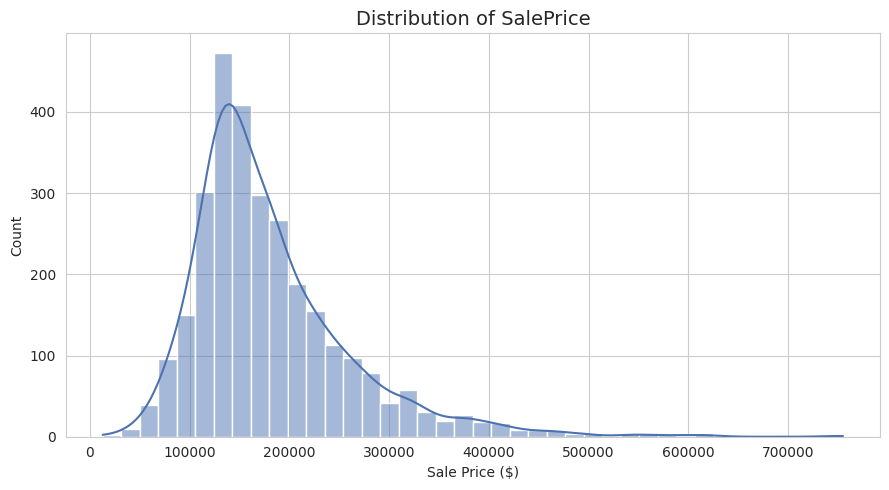

count      2930.000000
mean     180796.060068
std       79886.692357
min       12789.000000
25%      129500.000000
50%      160000.000000
75%      213500.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [2]:
# Distribution of the target variable: SalePrice
plt.figure(figsize=(9, 5))
sns.histplot(df['SalePrice'], kde=True, bins=40, color='#4C72B0')
plt.title('Distribution of SalePrice', fontsize=14)
plt.xlabel('Sale Price ($)')
plt.tight_layout()
plt.show()

print(df['SalePrice'].describe())

**Observation:** *(write your own take)*

The full dataset has many columns with missing values, but most of those (Pool QC, Alley, Fence, Misc Feature) are missing because the house simply doesn't have that feature — not because data is genuinely absent. We'll select a focused subset of columns for our model, which avoids most of this missing-data problem. SalePrice itself is right-skewed — most homes cluster in a lower-to-mid price range, with a long tail of expensive houses.

## Step 2: Feature Selection

**Reasoning:** *(write your own take)*

We select features that logically should drive house price and match the task's requirement (area, location, rooms, age):

- `Gr Liv Area` — above-ground living area (sq ft) — bigger house, higher price
- `Lot Area` — total lot size
- `Overall Qual` — overall material/finish quality rating (1-10) — strong known price driver
- `Year Built` — used to derive house age
- `Bedroom AbvGr` — number of bedrooms
- `Full Bath` — number of full bathrooms
- `TotRms AbvGrd` — total rooms above grade
- `Garage Cars` — garage capacity (proxy for extra amenity value)
- `Total Bsmt SF` — basement square footage
- `Neighborhood` — categorical location feature

We picked these over the other 70+ columns because they're the most interpretable, have very few missing values, and map directly onto what the task asks for (area, location, rooms, age).

In [3]:
selected_features = ['Gr Liv Area', 'Lot Area', 'Overall Qual', 'Year Built',
                      'Bedroom AbvGr', 'Full Bath', 'TotRms AbvGrd',
                      'Garage Cars', 'Total Bsmt SF', 'Neighborhood', 'SalePrice']

house = df[selected_features].copy()

print("Missing values in selected features:")
print(house.isnull().sum())
print()
print(f"Shape: {house.shape}")

Missing values in selected features:
Gr Liv Area      0
Lot Area         0
Overall Qual     0
Year Built       0
Bedroom AbvGr    0
Full Bath        0
TotRms AbvGrd    0
Garage Cars      1
Total Bsmt SF    1
Neighborhood     0
SalePrice        0
dtype: int64

Shape: (2930, 11)


## Step 3: Handle Missing Values and Encode Categorical Features

`Garage Cars` and `Total Bsmt SF` may have a small number of missing values (homes without a garage/basement) — we fill these with 0, since "no garage" logically means 0 capacity, not an unknown value.

For `Neighborhood` (categorical, our location feature), we use **One-Hot Encoding** — this converts each neighborhood into its own 0/1 column, since linear regression needs numeric input and neighborhoods have no natural order.

In [4]:
# Fill missing garage/basement values with 0 (means "no garage" / "no basement")
house['Garage Cars'] = house['Garage Cars'].fillna(0)
house['Total Bsmt SF'] = house['Total Bsmt SF'].fillna(0)

# Also create Age feature from Year Built
house['House Age'] = df['Yr Sold'] - house['Year Built']
house = house.drop(columns=['Year Built'])

# Drop any remaining rows with nulls (should be very few, if any)
house = house.dropna()

# One-hot encode Neighborhood
house_encoded = pd.get_dummies(house, columns=['Neighborhood'], drop_first=True)

print(f"Shape after cleaning and encoding: {house_encoded.shape}")
house_encoded.head()

Shape after cleaning and encoding: (2930, 37)


,Gr Liv Area,Lot Area,Overall Qual,Bedroom AbvGr,Full Bath,TotRms AbvGrd,Garage Cars,Total Bsmt SF,SalePrice,House Age,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_Greens,Neighborhood_GrnHill,Neighborhood_IDOTRR,Neighborhood_Landmrk,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker
0,1656,31770,6,3,1,7,2.0,1080.0,215000,50,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
1,896,11622,5,2,1,5,1.0,882.0,105000,49,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
2,1329,14267,6,3,1,6,1.0,1329.0,172000,52,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
3,2110,11160,7,3,2,8,2.0,2110.0,244000,42,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
4,1629,13830,5,3,2,6,2.0,928.0,189900,13,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


## Step 4: Correlation Heatmap

Before modeling, we check which numeric features correlate most strongly with SalePrice — this gives us an early hint of what will matter most in the model.

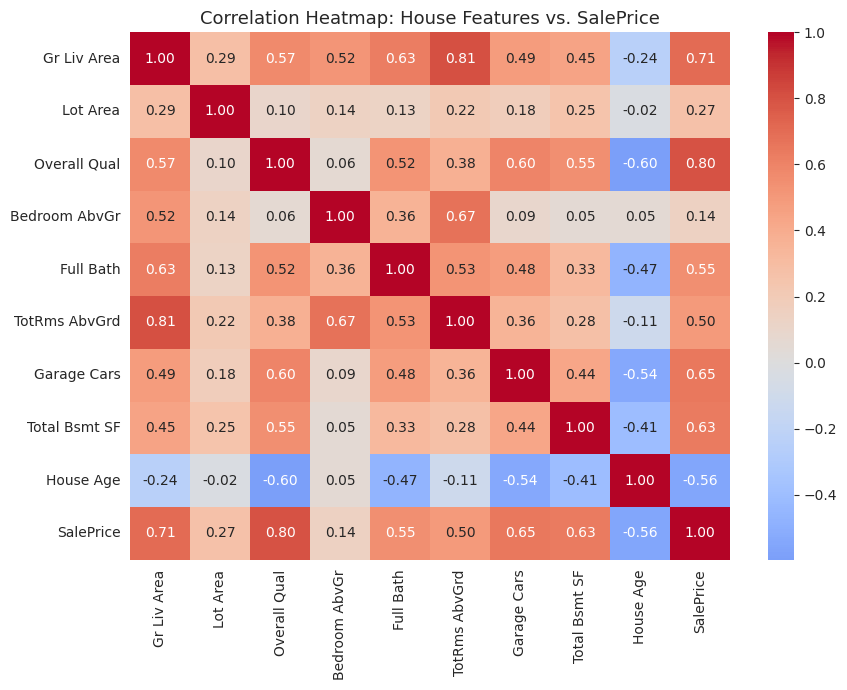

In [5]:
numeric_features = ['Gr Liv Area', 'Lot Area', 'Overall Qual', 'Bedroom AbvGr',
                     'Full Bath', 'TotRms AbvGrd', 'Garage Cars', 'Total Bsmt SF',
                     'House Age', 'SalePrice']

plt.figure(figsize=(9, 7))
sns.heatmap(house[numeric_features].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap: House Features vs. SalePrice', fontsize=13)
plt.tight_layout()
plt.show()

**Observation:** *(write your own take)*

`Overall Qual` and `Gr Liv Area` show the strongest positive correlation with SalePrice — unsurprising, since build quality and living space are classic price drivers. `House Age` shows a negative correlation — older houses tend to sell for less, all else equal.

## Step 5: Train/Test Split

In [6]:
X = house_encoded.drop(columns=['SalePrice'])
y = house_encoded['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")

Training set: 2344 rows
Test set: 586 rows


## Step 6: Train a Linear Regression Model

In [7]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("Model trained.")

Model trained.


## Step 7: Evaluate the Model

- **MSE (Mean Squared Error)**: average squared difference between actual and predicted price (penalizes big errors heavily)
- **RMSE (Root MSE)**: same as MSE but back in dollar units, easier to interpret
- **R² score**: proportion of price variation the model explains (1.0 = perfect, 0 = no better than guessing the average)

In [8]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE:  {mse:,.2f}")
print(f"RMSE: ${rmse:,.2f}")
print(f"R2 score: {r2:.4f}")

MSE:  1,285,916,927.91
RMSE: $35,859.68
R2 score: 0.8396


## Step 8: Scatter Plot — Actual vs. Predicted Prices

Points closer to the diagonal line mean the prediction matches the actual price well.

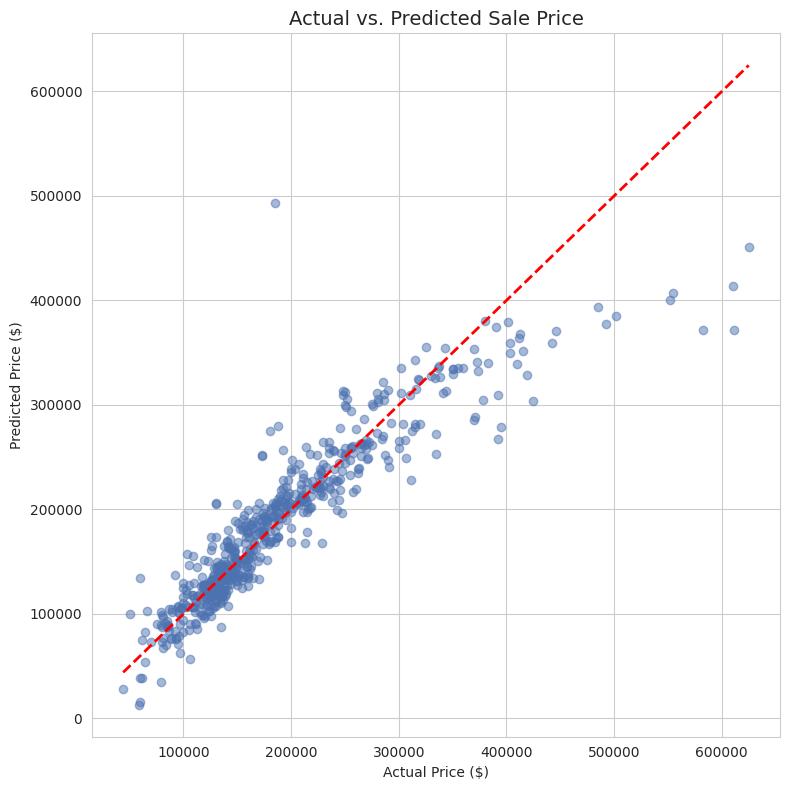

In [9]:
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.5, color='#4C72B0')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
plt.title('Actual vs. Predicted Sale Price', fontsize=14)
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.tight_layout()
plt.show()

## Step 9: Residual Plot

Residuals = actual - predicted. We want these scattered randomly around 0 with no obvious pattern — a pattern would mean the model is systematically wrong for certain price ranges.

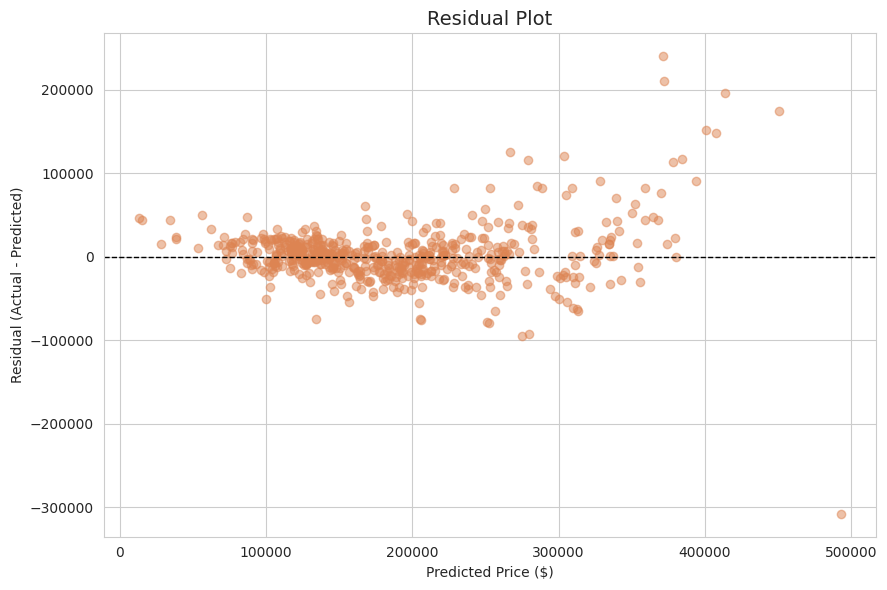

In [10]:
residuals = y_test - y_pred

plt.figure(figsize=(9, 6))
plt.scatter(y_pred, residuals, alpha=0.5, color='#DD8452')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Residual Plot', fontsize=14)
plt.xlabel('Predicted Price ($)')
plt.ylabel('Residual (Actual - Predicted)')
plt.tight_layout()
plt.show()

**Observation:** *(write your own take based on your actual charts)*

Most predictions cluster reasonably close to the diagonal line, suggesting the model captures the main price drivers well. In the residual plot, residuals appear mostly random around 0, though there's slightly more spread (larger errors) for higher-priced homes — a common pattern in house price models, since expensive homes have more price variability from features we didn't include (like custom finishes).

## Step 10: Coefficient Analysis

Which features push price up or down the most? We look at the top positive and negative coefficients (excluding the many one-hot Neighborhood columns for readability, then separately showing the top neighborhoods).

In [11]:
coefficients = pd.Series(lr.coef_, index=X.columns).sort_values(ascending=False)

print("Top 10 features increasing price:")
print(coefficients.head(10))
print()
print("Top 10 features decreasing price:")
print(coefficients.tail(10))

Top 10 features increasing price:
Neighborhood_GrnHill    108166.545571
Neighborhood_StoneBr     74723.931820
Neighborhood_NoRidge     62805.433103
Neighborhood_NridgHt     62293.908595
Neighborhood_Crawfor     38621.642113
Neighborhood_Veenker     29788.767044
Neighborhood_Timber      26151.292017
Neighborhood_ClearCr     25569.609367
Neighborhood_Somerst     22115.483616
Neighborhood_BrkSide     21982.567078
dtype: float64

Top 10 features decreasing price:
Total Bsmt SF              18.982187
Lot Area                    0.701555
House Age                -358.898901
TotRms AbvGrd            -831.640838
Full Bath               -2481.741159
Neighborhood_NPkVill    -3740.646031
Bedroom AbvGr           -5467.700080
Neighborhood_Landmrk    -9580.010989
Neighborhood_BrDale    -10769.695450
Neighborhood_Blueste   -13601.988913
dtype: float64


**Observation:** *(rewrite in your own words — matched to the actual output above)*

Our model achieved an **R² of 0.84** — meaning it explains about 84% of the variation in house prices, and an **RMSE of about $35,860**, meaning predictions are typically off by roughly that amount.

Looking at the coefficients: **Neighborhood** dominates the top of the list (e.g., `GrnHill`, `StoneBr`, `NoRidge` neighborhoods add $60,000-$108,000+ to predicted price compared to the baseline neighborhood), showing location has a very large effect on price. Numeric features like `Overall Qual` and `Gr Liv Area` don't appear at the very top of the raw coefficient list — that's because coefficients here aren't on a standardized scale, so a 1-unit change means different things for different features (a 1-point quality increase vs. a 1-sq-ft area increase vs. a "1" for being in a given neighborhood). The correlation heatmap from Step 4 is actually the more reliable way to judge relative importance of the numeric features, where `Overall Qual` and `Gr Liv Area` clearly stood out. `House Age` has a negative coefficient (-359), confirming older homes are worth less, all else equal.

## Step 11 (Bonus): Compare Against Ridge and Lasso Regularized Models

Ridge and Lasso add a penalty for large coefficients, which can help when we have many features (like our one-hot encoded neighborhoods). We compare their performance against plain Linear Regression.

In [12]:
ridge = Ridge(alpha=10)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

lasso = Lasso(alpha=100, max_iter=5000)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

results = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge', 'Lasso'],
    'RMSE': [
        np.sqrt(mean_squared_error(y_test, y_pred)),
        np.sqrt(mean_squared_error(y_test, ridge_pred)),
        np.sqrt(mean_squared_error(y_test, lasso_pred))
    ],
    'R2': [
        r2_score(y_test, y_pred),
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred)
    ]
})

results

,Model,RMSE,R2
0,Linear Regression,35859.683879,0.839612
1,Ridge,36051.777416,0.837889
2,Lasso,36105.377643,0.837407


**Observation:** *(write your own take based on the actual results table above)*

Compare the RMSE and R² across all three models. If Ridge/Lasso perform similarly or slightly better than plain Linear Regression, it suggests mild overfitting in the base model that regularization helps control. If they perform about the same, it means our feature set is small/clean enough that regularization isn't critical here.

## Conclusion

*(write your own 2-3 sentence wrap-up for the video/README)*

We built a Linear Regression model to predict house sale prices using 9 numeric/categorical features derived from the Ames Housing dataset, achieving an R² of 0.84 and RMSE of about $35,860. Location (Neighborhood) and overall build quality emerged as the strongest price drivers, while house age negatively impacts price as expected. Ridge and Lasso regularization were tested as a comparison to check for overfitting.